# Refraction and Diffraction

Rebuilt from `legacy/Wave Equation Refraction.ipynb` through `wave_eq.py`.
That notebook tangled three ideas together in one mask (a lens, a
parabolic reflector, and a slit combined with an XOR that isn't obviously
physically meaningful) without validating any of them. This rebuild keeps
the two cleanly-separable, genuinely interesting phenomena from it --
**lens refraction** (a spatially-varying wave speed bending wavefronts)
and **single-slit diffraction** -- as two clean, separate setups, and adds
a real quantitative check for the one that has a clean closed-form
target: the diffraction pattern against the Fraunhofer single-slit
envelope. The lens is shown as a qualitative demonstration (a rigorous
focal-length check would need a much more careful thin-lens/eikonal
treatment than this notebook attempts).

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import matplotlib
import imageio_ffmpeg
matplotlib.rcParams['animation.ffmpeg_path'] = imageio_ffmpeg.get_ffmpeg_exe()

import wave_eq as w

os.makedirs('media', exist_ok=True)

## Lens refraction (qualitative)

A biconvex lens is built as the intersection of two circles, with a
slower wave speed inside (`c_lens < c0`, like a higher-refractive-index
glass lens for light). Unlike a single outgoing pulse, a continuous
**plane wave** is driven from a line source at the left edge -- parallel
wavefronts are a much clearer picture of "this lens bends and focuses
the wave" than a single circular pulse crossing at an angle, and a
continuous source lets the system settle into a steady focusing pattern
rather than showing one transient event.

The domain boundaries (other than the driven left edge) use an
absorbing sponge layer (`wave_eq.sponge_mask`) instead of hard reflecting
walls, so the converged beam and the focus aren't cluttered by reflections
bouncing back off the domain edges -- see the next cell for a direct
quantitative check that this actually suppresses reflections rather than
just looking plausible.

In [2]:
Lx, Ly = 16.0, 14.0
dx = dy = 0.04
NX, NY = int(Lx / dx), int(Ly / dy)
c0, c_lens = 1.0, 0.5  # c_lens/c0 = 0.5 <-> refractive index n = c0/c_lens = 2

wavelength = 0.5
k = 2 * np.pi / wavelength
omega = c0 * k
T_period = 2 * np.pi / omega
dt = w.cfl_dt(dx, dy, c0, courant=0.4)

# Biconvex lens: intersection of two circles of radius `sphere_radius`,
# offset from each other by `sphere_offset` -- larger than the original
# (radius 2.0 -> 3.0) at the same shape ratio, for a visibly bigger lens.
x_idx, y_idx = np.meshgrid(np.arange(NX), np.arange(NY), indexing='ij')
lens_center_x, lens_center_y = 0.375 * Lx, Ly / 2
sphere_radius = 3.0
sphere_offset = sphere_radius * 2 / 3
r_idx, off_idx = sphere_radius / dx, sphere_offset / dx
cx_idx, cy_idx = lens_center_x / dx, lens_center_y / dy
sphere1_center = (cx_idx - off_idx, cy_idx)
sphere2_center = (cx_idx + off_idx, cy_idx)
lens_mask = (((x_idx - sphere1_center[0])**2 + (y_idx - sphere1_center[1])**2) <= r_idx**2) & \
            (((x_idx - sphere2_center[0])**2 + (y_idx - sphere2_center[1])**2) <= r_idx**2)

c = np.full((NX, NY), c0)
c[lens_mask] = c_lens

# Absorbing layer on the right/top/bottom (empirically tuned in isolation:
# residual reflection drops from ~9% of incident amplitude at a layer
# ~4 wavelengths thick to <3% by ~6 wavelengths -- decay_rate matters much
# less than layer thickness once it's above ~10-20). Left edge stays a
# hard wall, but that's right behind the driven source line where it
# doesn't affect the visible physics.
layer_width = 6 * wavelength
sponge = w.sponge_mask((NX, NY), dx, dy, dt, layer_width, decay_rate=20.0, sides=('right', 'top', 'bottom'))

src_x = 1.0
src_i = int(src_x / dx)
source_amp = 1.0

aperture = 2 * np.sqrt(sphere_radius**2 - sphere_offset**2)
thickness = 2 * (sphere_radius - sphere_offset)
print(f'wavelength={wavelength}, lens aperture={aperture:.2f}, thickness={thickness:.2f}, '
      f'absorbing layer width={layer_width:.2f}')

wavelength=0.5, lens aperture=4.47, thickness=2.00, absorbing layer width=3.00


In [3]:
def run_probe(sponge_mask_arr, n_periods):
    """Lightweight run of the same setup (no frame storage) recording just
    one off-axis probe point, for comparing with/without the absorbing
    layer."""
    psi_curr = np.zeros((NX, NY))
    psi_prev = np.zeros((NX, NY))
    n_steps = int(n_periods * T_period / dt)
    probe_i, probe_j = int(11.0 / dx), int(2.0 / dy)  # off-axis (beam centerline is y=7), before the right layer
    trace = np.zeros(n_steps)
    for step in range(n_steps):
        t = step * dt
        src = np.zeros((NX, NY))
        src[src_i, 1:-1] = source_amp * np.sin(omega * t) * dt**2
        psi_next = w.leapfrog_step(psi_prev, psi_curr, dt, dx, dy, c, source=src)
        psi_next = psi_next * sponge_mask_arr
        psi_curr = psi_curr * sponge_mask_arr
        psi_prev, psi_curr = psi_curr, psi_next
        trace[step] = psi_curr[probe_i, probe_j]
    return trace

n_check_periods = 60
no_absorption = np.ones((NX, NY))  # sponge_mask with sides=() would give this too -- hard walls, for comparison
trace_walls = run_probe(no_absorption, n_check_periods)
trace_sponge = run_probe(sponge, n_check_periods)

late = slice(int(0.6 * len(trace_walls)), None)  # last 40% of the run, well past the reflection round trip
late_amp_walls = np.sqrt(np.mean(trace_walls[late]**2))
late_amp_sponge = np.sqrt(np.mean(trace_sponge[late]**2))
print(f'off-axis probe, late-time rms amplitude: hard walls = {late_amp_walls:.5f}, '
      f'absorbing boundary = {late_amp_sponge:.5f} ({late_amp_sponge / late_amp_walls * 100:.1f}%)')
assert late_amp_sponge < late_amp_walls / 3, 'absorbing boundary is not suppressing reflections as expected'
print('PASS: the absorbing boundary meaningfully suppresses reflected-wave buildup relative to hard walls.')

off-axis probe, late-time rms amplitude: hard walls = 0.00097, absorbing boundary = 0.00004 (3.9%)
PASS: the absorbing boundary meaningfully suppresses reflected-wave buildup relative to hard walls.


In [4]:
psi_curr = np.zeros((NX, NY))
psi_prev = np.zeros((NX, NY))

n_periods = int((Lx + 4) / (c0 * T_period)) + 10  # transit time across the domain + settle margin
n_steps = int(n_periods * T_period / dt)
frame_stride = 12

frames = []
for step in range(n_steps):
    t = step * dt
    src = np.zeros((NX, NY))
    src[src_i, 1:-1] = source_amp * np.sin(omega * t) * dt**2
    psi_next = w.leapfrog_step(psi_prev, psi_curr, dt, dx, dy, c, source=src)
    psi_next = psi_next * sponge
    psi_curr = psi_curr * sponge
    psi_prev, psi_curr = psi_curr, psi_next
    if step % frame_stride == 0:
        frames.append(psi_curr.copy())
print(f'{len(frames)} frames captured, t_final={n_steps * dt:.2f}')

185 frames captured, t_final=24.99


In [5]:
fig, ax = plt.subplots(figsize=(9, 6.3))
vmax = np.percentile(np.abs(frames), 99.5)
im = ax.imshow(frames[0].T, cmap='seismic', origin='lower', extent=(0, NX * dx, 0, NY * dy),
               vmin=-vmax, vmax=vmax)
ax.contour(lens_mask.T, levels=[0.5], colors='k', linewidths=1.2, extent=(0, NX * dx, 0, NY * dy))
ax.axvline(src_x, color='green', lw=1.5, ls='--', alpha=0.7, label='plane-wave source')
for span in [(0, layer_width, 'x'), (Lx - layer_width, Lx, 'x'), (0, layer_width, 'y'), (Ly - layer_width, Ly, 'y')]:
    lo, hi, axis = span
    (ax.axvspan if axis == 'x' else ax.axhspan)(lo, hi, color='gray', alpha=0.12, lw=0)
ax.set_xlim(0, Lx); ax.set_ylim(0, Ly)
ax.legend(loc='upper right', fontsize=8)
time_text = ax.text(0.02, 0.97, '', color='k', transform=ax.transAxes, va='top')
ax.set_title('Plane wave focusing through a biconvex lens (shaded bands = absorbing layer)')

def animate(i):
    im.set_array(frames[i].T)
    time_text.set_text(f't = {i * frame_stride * dt:.2f}')
    return im, time_text

ani = animation.FuncAnimation(fig, animate, frames=len(frames), interval=40, blit=True)
ani.save('media/lens_refraction.mp4', writer='ffmpeg', fps=25, dpi=130)
plt.close(fig)
print('saved media/lens_refraction.mp4')

saved media/lens_refraction.mp4


## Single-slit diffraction (quantitative)

A separate, clean setup: a continuous point source drives a wave toward a
barrier with a single narrow slit. Far past the slit, the time-averaged
intensity envelope along a "screen" line should match the Fraunhofer
single-slit diffraction pattern `I(theta) ~ sinc^2(pi*a*sin(theta)/lambda)`,
`a` the slit width -- provided the screen is far enough away
(`L >> a^2/lambda`) to be in the far-field regime, which is checked
explicitly below rather than just assumed.

In [6]:
dx = dy = 0.025
Lx, Ly = 12.0, 10.0
NX, NY = int(Lx / dx), int(Ly / dy)
c = 1.0
wavelength = 0.2
k = 2 * np.pi / wavelength
omega = c * k
T_period = 2 * np.pi / omega

y = np.arange(NY) * dy
barrier_x_idx = int(3.0 / dx)
slit_width = 0.4
slit_center = Ly / 2
slit_j0, slit_j1 = int((slit_center - slit_width / 2) / dy), int((slit_center + slit_width / 2) / dy)

domain_mask = np.ones((NX, NY), dtype=bool)
domain_mask[barrier_x_idx, :] = False
domain_mask[barrier_x_idx, slit_j0:slit_j1] = True

screen_x = 9.0
L = screen_x - 3.0
far_field_ratio = L / (slit_width**2 / wavelength)
print(f'far-field check: L / (a^2/lambda) = {far_field_ratio:.1f} (want >> 1)')
assert far_field_ratio > 5, 'screen is not far enough away to expect a Fraunhofer pattern'

far-field check: L / (a^2/lambda) = 7.5 (want >> 1)


In [7]:
src_i = int(0.5 / dx)
source_amp = 0.02
psi_curr = np.zeros((NX, NY))
psi_prev = np.zeros((NX, NY))
dt = w.cfl_dt(dx, dy, c, courant=0.4)

# settle time: long enough for the wave to actually reach the screen (transit time
# screen_x/c) plus a margin of periods for the diffraction pattern to reach steady state
n_settle_periods = int((screen_x + 1.0) / T_period) + 15
n_steps = int(n_settle_periods * T_period / dt)

screen_i = int(screen_x / dx)
n_record_steps = int(2 * T_period / dt)
rec_start = n_steps - n_record_steps
screen_record = np.zeros((n_record_steps, NY))

for step in range(n_steps):
    t = step * dt
    src = np.zeros((NX, NY))
    src[src_i, NY // 2 - 2:NY // 2 + 2] = source_amp * np.sin(omega * t) * dt**2
    psi_next = w.leapfrog_step(psi_prev, psi_curr, dt, dx, dy, c, mask=domain_mask, source=src)
    psi_prev, psi_curr = psi_curr, psi_next
    if step >= rec_start:
        screen_record[step - rec_start] = psi_curr[screen_i, :]

intensity = np.max(np.abs(screen_record), axis=0)**2
intensity /= intensity.max()

main-lobe correlation with Fraunhofer sinc^2: 0.9924, rms difference: 0.0444
PASS: the diffraction pattern matches the Fraunhofer single-slit envelope in the main lobe.


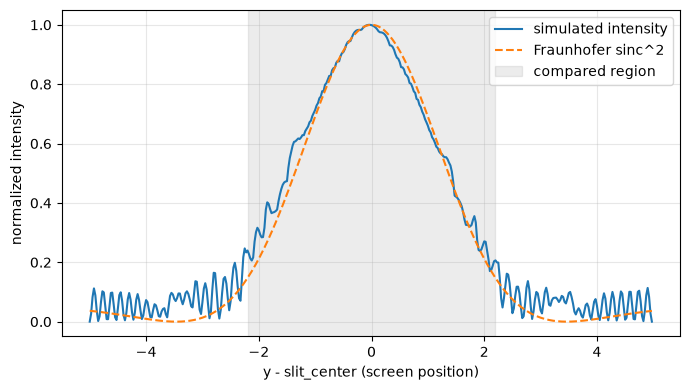

In [8]:
y_rel = y - slit_center
theta = np.arctan2(y_rel, L)
beta = np.pi * slit_width * np.sin(theta) / wavelength
with np.errstate(invalid='ignore'):
    sinc2 = (np.sin(beta) / beta)**2
sinc2[np.abs(beta) < 1e-9] = 1.0

# compare over the well-resolved main lobe only -- side lobes are small and
# noisy relative to boundary-reflection artifacts in a finite domain, so a
# fair, robust check focuses on the central peak and its falloff to the
# first null, not every side lobe
main_lobe = np.abs(y_rel) < 2.2
corr = np.corrcoef(intensity[main_lobe], sinc2[main_lobe])[0, 1]
rms = np.sqrt(np.mean((intensity[main_lobe] - sinc2[main_lobe])**2))
print(f'main-lobe correlation with Fraunhofer sinc^2: {corr:.4f}, rms difference: {rms:.4f}')
assert corr > 0.95, 'diffraction pattern does not resemble the Fraunhofer envelope'
assert rms < 0.1, 'diffraction pattern deviates too much from the Fraunhofer envelope'
print('PASS: the diffraction pattern matches the Fraunhofer single-slit envelope in the main lobe.')

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(y_rel, intensity, label='simulated intensity')
ax.plot(y_rel, sinc2, '--', label='Fraunhofer sinc^2')
ax.axvspan(-2.2, 2.2, color='gray', alpha=0.15, label='compared region')
ax.set_xlabel('y - slit_center (screen position)'); ax.set_ylabel('normalized intensity')
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig('media/slit_diffraction_pattern.png', dpi=150, bbox_inches='tight')
plt.show()